<b>Olist E-Commerce EDA:

Анализ 100K+ заказов бразильского маркетплейса</b>

In [24]:
import sys
!{sys.executable} -m pip install numpy==1.26.4


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: /opt/anaconda3/bin/python -m pip install --upgrade pip


<b>1. Setup & Data loading</b>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")

In [2]:
path = Path("/Users/tolkyn.zhagipar/Desktop/pet-projects/data-analytics/archive")

orders = pd.read_csv(path / "olist_orders_dataset.csv")
items = pd.read_csv(path / "olist_order_items_dataset.csv")
customers = pd.read_csv(path / "olist_customers_dataset.csv")
payments = pd.read_csv(path / "olist_order_payments_dataset.csv")
reviews = pd.read_csv(path / "olist_order_reviews_dataset.csv")

In [5]:
print(orders.shape, items.shape, customers.shape)
orders.head(3)

(99441, 8) (112650, 7) (99441, 5)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00


<b> 2. Data quality checking:

Missing values, duplicates, data types</b>

In [8]:
# Checking for missing data
for name, df in [("orders",orders),("items",items),("customers",customers)]:
    missing = df.isnull().sum()
    print(f"\n{name}:\n", missing[missing > 0])


orders:
 order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
dtype: int64

items:
 Series([], dtype: int64)

customers:
 Series([], dtype: int64)


In [10]:
missing_percent = orders.isnull().mean()*100
print(missing_percent.sort_values(ascending=False))

order_delivered_customer_date    2.981668
order_delivered_carrier_date     1.793023
order_approved_at                0.160899
order_id                         0.000000
customer_id                      0.000000
order_status                     0.000000
order_purchase_timestamp         0.000000
order_estimated_delivery_date    0.000000
dtype: float64


In [12]:
# Leaving only delivered orders for proper analysis

orders = orders[orders['order_status'] == 'delivered']
print("Orders shape after cleaning:", orders.shape)

orders.isnull().sum()

Orders shape after cleaning: (96478, 8)


order_id                          0
customer_id                       0
order_status                      0
order_purchase_timestamp          0
order_approved_at                14
order_delivered_carrier_date      2
order_delivered_customer_date     8
order_estimated_delivery_date     0
dtype: int64

In [14]:
# Duplicates
print("Duplicates of orders:", orders.duplicated().sum())
print("Duplicates of items:", items.duplicated().sum())

Duplicates of orders: 0
Duplicates of items: 0


In [16]:
# Date convertion
date_cols = ['order_purchase_timestamp','order_approved_at',
             'order_delivered_customer_date','order_estimated_delivery_date']
for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

<b>2. Purchase analysis:

Seasonality, trends, categories </b>

In [19]:
# Merging tables
df = orders.merge(items, on='order_id').merge(payments, on='order_id')
df['month'] = df['order_purchase_timestamp'].dt.to_period('M')

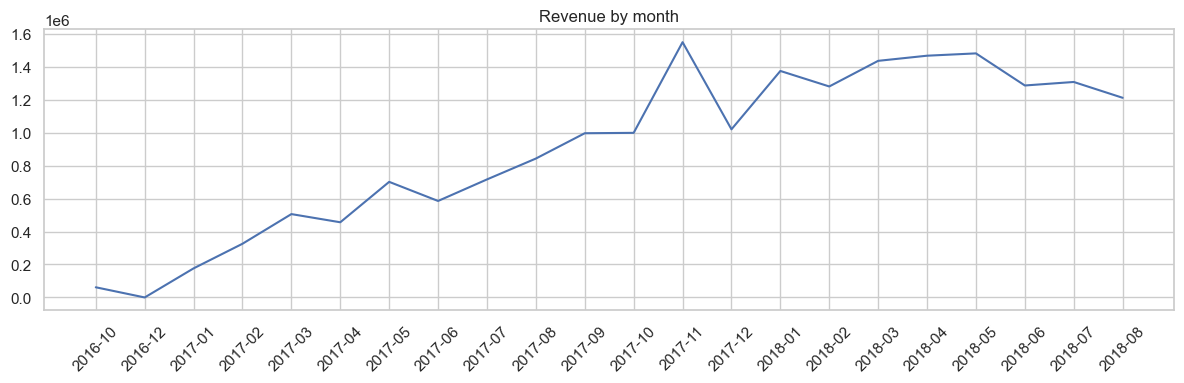

In [21]:
# Revenue by month
monthly = df.groupby('month')['payment_value'].sum().reset_index()
plt.figure(figsize=(12,4))
plt.plot(monthly['month'].astype(str), monthly['payment_value'])
plt.xticks(rotation=45)
plt.title('Revenue by month')
plt.tight_layout()

In [23]:
# Average bill
avg_bill = df.groupby('order_id')['payment_value'].sum().mean()
median_bill = df.groupby('order_id')['payment_value'].sum().median()
print('Average bill:', avg_bill)
print('Median bill:', median_bill)

Average bill: 204.98316116794675
Median bill: 109.5


<b>4. Customers analysis:

LTV, retention, new/repeated customers</b>

In [75]:
# merge orders with unique customer id
orders_with_unique = orders.merge(
    customers[['customer_id','customer_unique_id']],
    on='customer_id'
)

# count orders per real customer
customer_orders = orders_with_unique.groupby('customer_unique_id')['order_id'].count()

# repeat customers and new customer with only one order
repeat_customers = (customer_orders > 1).sum()
new_customers = (customer_orders == 1).sum()
total_customers = len(customer_orders)
new_percent = new_customers/total_customers*100
repeat_percent = repeat_customers/total_customers*100
print(f"Total customers: {total_customers}")
print(f"New customers: {new_customers } ({round(new_percent)}%)")
print(f"Repeat customers: {repeat_customers } ({round(repeat_percent)}%)")

Total customers: 93358
New customers: 90557 (97%)
Repeat customers: 2801 (3%)


In [28]:
# LTV — revenue by customer
ltv = df.groupby('customer_id')['payment_value'].sum()
avg_ltv = ltv.mean().round(2)
print('Average LTV:', avg_ltv)
print('Top 10% customers give:', ltv.quantile(0.9).round(2))

Average LTV: 204.98
Top 10% customers give: 383.66


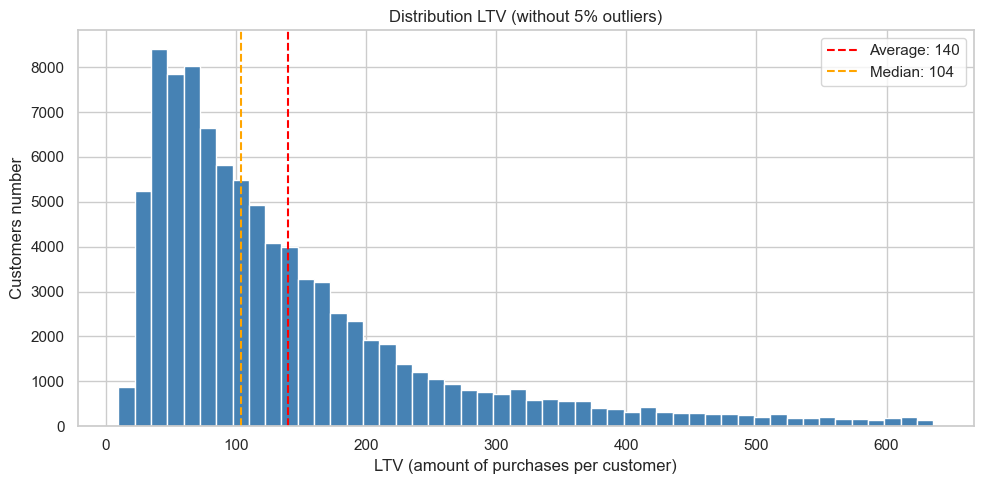

In [30]:
# LTV without 5% outliers, looking up tp 95th percentile
ltv_clean = ltv[ltv < ltv.quantile(0.95)]

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(ltv_clean, bins=50, color='steelblue', edgecolor='white')

# Vertical lines on graph with avg and median
ax.axvline(ltv_clean.mean(), color='red', linestyle='--', label=f'Average: {ltv_clean.mean():.0f}')
ax.axvline(ltv_clean.median(), color='orange', linestyle='--', label=f'Median: {ltv_clean.median():.0f}')

ax.set_title('Distribution LTV (without 5% outliers)')
ax.set_xlabel('LTV (amount of purchases per customer)')
ax.set_ylabel('Customers number')
ax.legend()
plt.tight_layout()
plt.show()

In [32]:
# Cohort analysis
orders['cohort'] = orders.groupby('customer_id')['order_purchase_timestamp']\
    .transform('min').dt.to_period('M')
orders['order_month'] = orders['order_purchase_timestamp'].dt.to_period('M')
cohort_data = orders.groupby(['cohort','order_month'])['customer_id'].nunique()

In [34]:
orders['cohort_month'] = orders.groupby('customer_id')['order_purchase_timestamp']\
    .transform('min').dt.to_period('M')
orders['order_month'] = orders['order_purchase_timestamp'].dt.to_period('M')
orders['cohort_index'] = (
    orders['order_month'] - orders['cohort_month']
).apply(lambda x: x.n)

cohort_data = orders.groupby(['cohort_month','cohort_index'])['customer_id']\
    .nunique().reset_index()

cohort_table = cohort_data.pivot(index='cohort_month',
                                 columns='cohort_index',
                                 values='customer_id')

cohort_size = cohort_table.iloc[:,0]
retention = cohort_table.divide(cohort_size, axis=0)

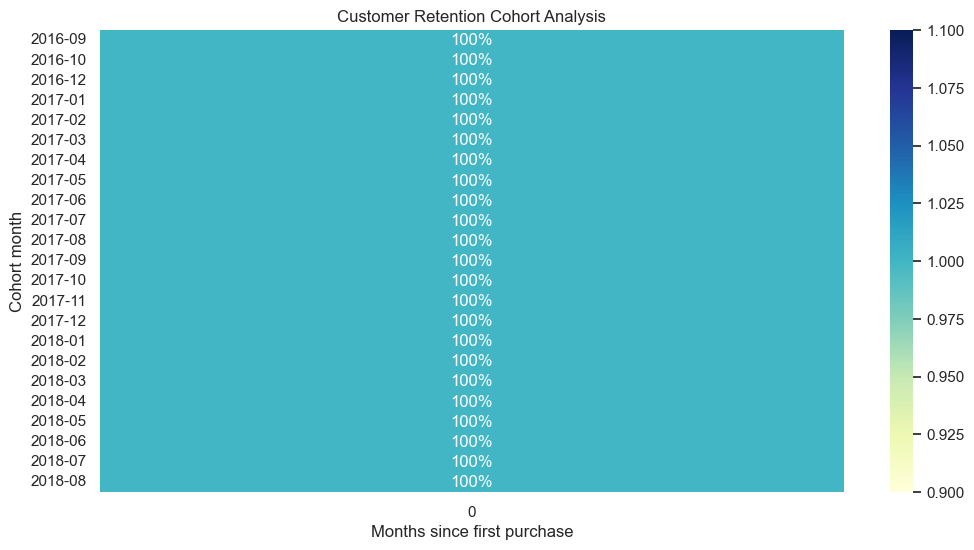

In [36]:
# Heatmap for cohort analysis
plt.figure(figsize=(12,6))

sns.heatmap(
    retention,
    annot=True,
    fmt='.0%',
    cmap="YlGnBu"
)

plt.title("Customer Retention Cohort Analysis")
plt.xlabel("Months since first purchase")
plt.ylabel("Cohort month")
plt.show()

<b>5. Delivery analysis:

Dates, latecomers, relation with rates</b>

In [39]:
# Delivery time
orders['delivery_days'] = (orders['order_delivered_customer_date'] 
    - orders['order_purchase_timestamp']).dt.days
orders['late'] = orders['order_delivered_customer_date'] > orders['order_estimated_delivery_date']
late_orders = orders['late'].mean().round(3)*100
print('% late_orders:', late_orders)
print('Delivery days analysis:')
orders['delivery_days'].describe()

% late_orders: 8.1
Delivery days analysis:


count    96470.000000
mean        12.093604
std          9.551380
min          0.000000
25%          6.000000
50%         10.000000
75%         15.000000
max        209.000000
Name: delivery_days, dtype: float64

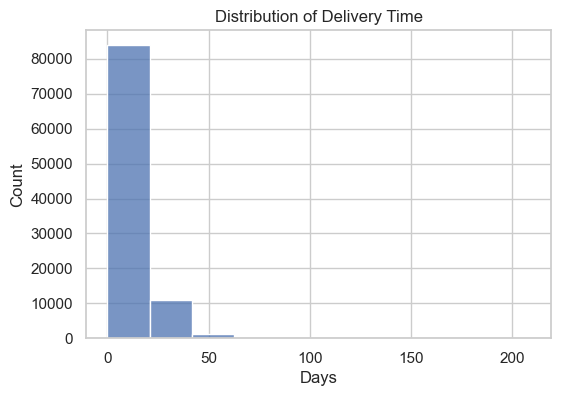

In [41]:
# Visualising distribution of delivery time
# X — how many days it took to deliver
# Y — how many orders were delivered in these days
plt.figure(figsize=(6,4))
sns.histplot(orders['delivery_days'], bins=10)
plt.title("Distribution of Delivery Time")
plt.xlabel("Days")
plt.show()

Text(0.5, 1.0, 'Average rate: on time vs late')

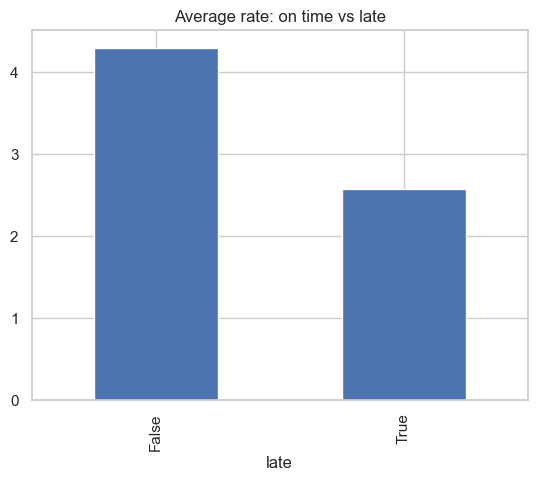

In [43]:
# Relation of review with late orders
df_rev = orders.merge(reviews, on='order_id')
df_rev.groupby('late')['review_score'].mean().plot(kind='bar')
plt.title('Average rate: on time vs late')

<b>6. Geographic analysis</b>

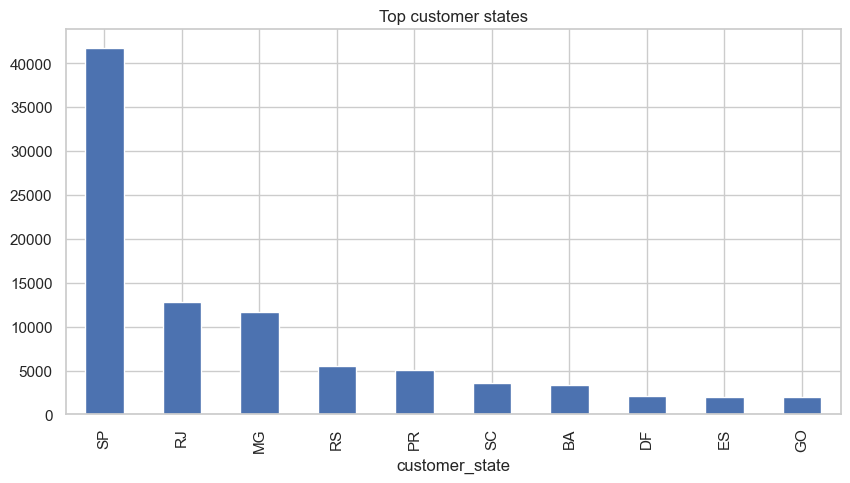

In [46]:
customers_state = customers['customer_state'].value_counts()

plt.figure(figsize=(10,5))
customers_state.head(10).plot(kind='bar')
plt.title("Top customer states")
plt.show()

<b>7. Key insights:

Dates, lateness, relation with rates</b>

In [51]:
# Insights table
insights = {
    'All orders': len(orders),
    'Average bill': avg_bill,
    'Repeat customers %': repeat_percent,
    '% late orders': late_orders,
    'Average LTV': avg_ltv,
}
pd.Series(insights).to_frame('Значение')

,Значение
All orders,96478.000000
Average bill,204.983161
Repeat customers %,0.000000
% late orders,8.100000
Average LTV,204.980000


**From the analysis above it is clear**: 
1. Data Scale
96,478 delivered orders from the Brazilian marketplace Olist were analyzed.

2. Average Order vs. Median
The average order is 205, but the median is only 109.5.

A gap of almost 2 times indicates that a small number of large orders
is significantly pushing the average up. For marketing, the median should be used as a guide.

3. Retention is a Critical Issue
100% of customers made only 1 order. Repeat purchases are 0%.
This indicates either a retention issue or a specific data structure (each order has a new customer ID). Further research is required.

4. Delivery is late in 8.1% of cases
One in 12 orders arrives later than promised.
The average delivery time is 12 days, but the maximum is 209 days.

5. Delays lower the rating
Orders delivered on time receive a higher review score
than those delivered late—a direct link between delivery times and customer satisfaction.

6. LTV is concentrated in a small group
Average LTV is $205. The top 10% of buyers spend $384 and above—
almost twice the average. High potential for segmentation.

In [82]:
# Save cleaned data for Tableau
df.to_csv('olist_clean.csv', index=False)
orders[['order_id','customer_id','order_purchase_timestamp',
        'delivery_days','late']].to_csv('orders_clean.csv', index=False)